#### 2) a.

Como as colunas não estão identificadas no dataset *"adult.data"* vamos assumir os nomes definidos em *"adult.names"*, no final do documento (linhas 97-110).

In [47]:
import pandas as pd

# From adult.names
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

# Load dataset
df = pd.read_csv("./data/adult.data", names=columns, skipinitialspace=True)

# Check missing data
missing_info = (df == "?").sum()
print(missing_info[missing_info > 0])

workclass         1836
occupation        1843
native-country     583
dtype: int64


2) a. **Conclusões**:
* As variáveis com valores em falta são: 'workclass', 'occupation' e 'native-country'

#### 2) b.

In [46]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32560 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
None


C:\Users\diogo\AppData\Local\Temp\ipykernel_15428\1055992325.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include=['object']).columns:


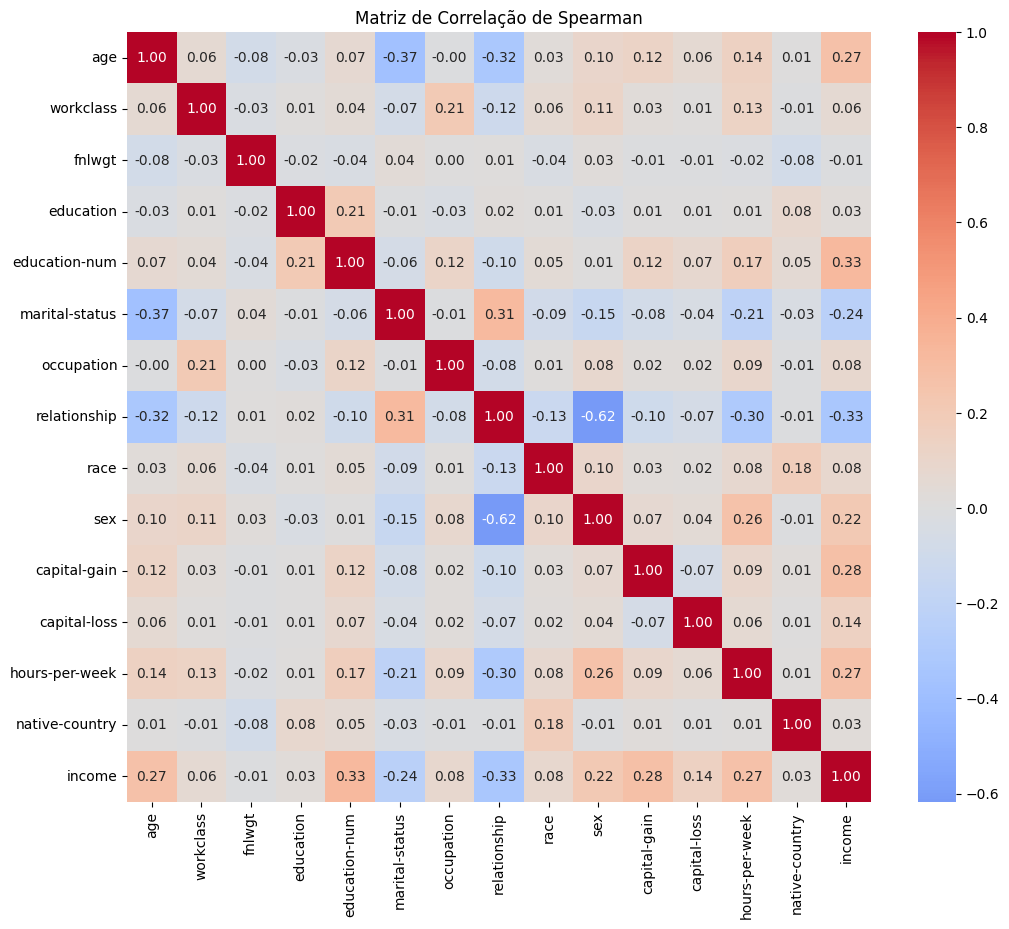

Correlação de Spearman em relação ao Rendimento (Income):
income            1.000000
education-num     0.329682
capital-gain      0.278159
age               0.272962
hours-per-week    0.269075
sex               0.215980
capital-loss      0.141042
occupation        0.082149
race              0.081976
workclass         0.064349
education         0.029648
native-country    0.028747
fnlwgt           -0.010738
marital-status   -0.236403
relationship     -0.329913
Name: income, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

spearman_corr = df_encoded.corr(method='spearman')

# 
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Matriz de Correlação de Spearman")
plt.show()

#
print("Correlação de Spearman em relação ao Rendimento (Income):")
print(spearman_corr['income'].sort_values(ascending=False))

In [ ]:
nominal_threshold = 10
for col in df.columns:
    if df[col].dtype == "str":
        print(f"{col:>15} -> Categórica Nominal")
        continue
    else:
        is_discrete = True

        for value in df[col]:
            if value % 1 > 0:
                is_discrete = False
                break

    if is_discrete:
        uniques = df[col].nunique()
        print(f"{col:>15} -> Numérica Discreta / Categórica {'Ordinal' if uniques > nominal_threshold else 'Nominal'}")
    else:
        print(f"{col:>15} -> Numérica Contínua")

            age -> Numérica Discreta / Categórica Ordinal
      workclass -> Categórica Nominal
         fnlwgt -> Numérica Discreta / Categórica Ordinal
      education -> Categórica Nominal
  education-num -> Numérica Discreta / Categórica Ordinal
 marital-status -> Categórica Nominal
     occupation -> Categórica Nominal
   relationship -> Categórica Nominal
           race -> Categórica Nominal
            sex -> Categórica Nominal
   capital-gain -> Numérica Discreta / Categórica Ordinal
   capital-loss -> Numérica Discreta / Categórica Ordinal
 hours-per-week -> Numérica Discreta / Categórica Ordinal
 native-country -> Categórica Nominal
         income -> Categórica Nominal


2) b. **Conclusões**:
* Pela informação fornecida no documento "adult.names", (linhas 97-110), sabemos que as variáveis 'workclass', 'occupation' e 'native-country' são texto, por isso podemos confiar no Dtype definido pelo *pandas* para identificar os campos numéricos. Que são 'age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss' e 'hours-per-week'.
* Sem um conhecimento semântico das variáveis não é viável atribuir uma natureza nominal ou ordinal para as categorias apenas com base nos valores do dataset. 
* Foi feito um estudo sobre a correlação entre variáveis, usando a correlação de Spearman, que em teoria, quando mais distante o valor estiver de 0 maior é a probabilidade da variável ser ordinal, isto é, a ordem de grandeza do seu valor tem maior impacto no sistema.
    * Nós sabemos pela descrição das variáveis em *"adult.names"* que a variável *"relationship"* é nominal, no entanto vemos uma grande influência no *"income"*, ou seja, os códigos numéricos atribuídos aos valores de *"relationship"* (ex.: Husband=0, Not-in-family=1, Own-child=2, etc.) fora gerados numa ordem que apresenta uma elevada correlação com o *"income"*, podendo induzir que a ordem importa.
    * Algo semelhante aconteceu com as variáveis *"education"* e *"education-enum"* que sabemos serem ordinais, no entanto, como a *"education"* é um texto, ao serem gerados os códigos numéricos para aplicação da correlação de Spearman, estes valores poderam ter sido ordenados alfabeticamente, o que destruiu a hierarquia (ex: "Bachelors" veio antes de "Masters" mas depois de "10th"), daí vermos uma forte correlação no *"education-enum"* com o *"income"* mas essa mesma correlação já não se verifica com a *"education"*, que partilham exatamente o mesmo valor semântico.
* Como não existe uma *regra de ouro* para distinguir os os valores numéricos Contínuos e Discretos, bem como definir valores Categóricos Nominais ou Ordeais sem uma interpretação semântica dos dados, a atribuição foi simplicifacada: 
    * Se valor for numérico no espaço "real" é Numérico Contínuo e não pode ser Categórico, 
    * Se for uma string é Categórico Nominal e não pode ser Numérico;
    * Se for um inteiro é contado o numero de occorrencias no dataset: 
        * Se tiver menos de 10 valores (configurável) considera-se Numérico Discreto e Categórico Nominal;
        * Senão é Numérico Discreto e Categórico Ordeal.

| variável | tipo |
|-|-|
|            age | Numérica Discreta / Categórica Ordinal |
|      workclass | Categórica Nominal |
|         fnlwgt | Numérica Discreta / Categórica Ordinal |
|      education | Categórica Nominal |
|  education-num | Numérica Discreta / Categórica Ordinal |
| marital-status | Categórica Nominal |
|     occupation | Categórica Nominal |
|   relationship | Categórica Nominal |
|           race | Categórica Nominal |
|            sex | Categórica Nominal |
|   capital-gain | Numérica Discreta / Categórica Ordinal |
|   capital-loss | Numérica Discreta / Categórica Ordinal |
| hours-per-week | Numérica Discreta / Categórica Ordinal |
| native-country | Categórica Nominal |
|         income | Categórica Nominal |

#### 2) c.

In [17]:
total_elements = len(df)
duplicated_mask = df.duplicated(keep=False) # Todos os que têm duplicados
duplicates_only_mask = df.duplicated(keep='first') # Contagem de instâncias "extra"

num_repeated = df.duplicated(keep='first').sum()
num_unique = total_elements - num_repeated

print(f"Original: {total_elements} | Repetidos: {num_repeated} | Únicos: {num_unique}")

Original: 32561 | Repetidos: 24 | Únicos: 32537


2) c. **Conclusões**:
* Existem 32561 registos no datagrame original, 24 repetidos e 32537 únicos.
* A análise foi realizada considerando as combinações de todas as colunas e não foi avaliado as repetições e uniques por coluna.

#### 2) d.

In [49]:
df_dup = df[df.duplicated(keep=False)]

dup_ind_country = (df_dup['native-country'] == "?").sum()
print(f"País de origem indeterminado: {dup_ind_country}")

dup_counts_sex = df_dup['sex'].value_counts()
# print(dup_counts_sex.head())
dup_ratio_fm = dup_counts_sex.get('Female', 0) / dup_counts_sex.get('Male', 1)
print(f"Rácio de mulheres para homens: {dup_ratio_fm}")

dup_high_income = (df_dup['income'] == ">50K").sum()
print(f"Salário superior a 50K: {dup_high_income}")

País de origem indeterminado: 2
Rácio de mulheres para homens: 0.5666666666666667
Salário superior a 50K: 4


2) d. **Conclusões**:
* Nos valores duplicados:
    * País de origem indeterminado: 2
    * Rácio de mulheres para homens: ≈0.57
    * Salário superior a 50K: 4

#### 2) e.

In [50]:
df_uni = df.drop_duplicates()

uni_ind_country = (df_uni['native-country'] == "?").sum()
print(f"País de origem indeterminado: {uni_ind_country}")

uni_ind_work = (df_uni['workclass'] == "?").sum()
print(f"Emprego indeterminado: {uni_ind_work}")

uni_both_ind = df_uni[(df_uni['native-country'] == "?") & (df_uni['workclass'] == "?")]
print(f"País e emprego indeterminados: {uni_both_ind.shape[0]}")

uni_both_ind_counts_sex = uni_both_ind['sex'].value_counts()
uni_both_ind_ratio_mf = uni_both_ind_counts_sex.get('Male', 0) / uni_both_ind_counts_sex.get('Female', 1)
print(f"Rácio de homens para mulheres (país e emprego indeterminados): {uni_both_ind_ratio_mf}")

uni_both_ind_low_income = (uni_both_ind['income'] == "<=50K").mean() * 100
print(f"Salário inferior a 50K (país e emprego indeterminados): {uni_both_ind_low_income:.2f}%")

País de origem indeterminado: 582
Emprego indeterminado: 1836
País e emprego indeterminados: 27
Rácio de homens para mulheres (país e emprego indeterminados): 0.8
Salário inferior a 50K (país e emprego indeterminados): 85.19%


2) e. **Conclusões**:
* Nos valores DEduplicados:
    * País de origem indeterminado: 582
    * Emprego indeterminado: 1836
    * País e emprego indeterminados: 27
        * Rácio de homens para mulheres: 0.8
        * Salário inferior a 50K (país e emprego indeterminados): 85.19%

#### 2) f.

A variável fnlwgt (Final Weight) representa o peso populacional. É um cálculo estatístico que indica quantas pessoas na população real aquele registo específico representa, baseando-se em características demográficas semelhantes.

Como o dataset é uma amostra da população, tecnicamente não faz sentido remover duplicados, pois é estatisticamente possível que existam duas pessoas com exatamente as mesmas características (idade, educação, ocupação, etc.) na vida real. No entanto, em Machine Learning, é boa prática remover duplicados exatos para evitar que o modelo dê "demasiada importância" (overfit) a esses registos específicos durante o treino.

#### 2) g.

1) Valores indeterminados identificados como "?", o que não é uma convenção, seria preferível uma string vazia que o pandas atribui automáticamente como *NaN* e seria mais fácil posteriomente de eliminar os indefinidos com o método *df.dropna()*
    * Uma forma de mitigar isto seria a conversão de "?" para *NaN* utilizando: `df.replace('?', np.nan)`
2) A primeira linha do dataset deveria ser a identificação das colunas, assim quando o dataset fosse importado pelo pandas, este atribuiria automáticamente o nome das colunas, sem necessidade de definição manual que é mais propícia ao erro.